> # ***Introduction***

Metabolic dysfunction-associated steatotic liver disease (MASLD), formerly known as non-alcoholic fatty liver disease (NAFLD), is one of the most common chronic liver conditions worldwide, affecting an estimated 25–30% of the global population. It is characterized by excessive fat accumulation in the liver (hepatic steatosis) in the absence of significant alcohol consumption, and is closely linked to obesity, type 2 diabetes, and metabolic syndrome.

MASLD exists on a spectrum of severity — from simple steatosis (fat accumulation with minimal inflammation) to steatohepatitis, fibrosis, and eventually cirrhosis if left untreated. Early and accurate detection is essential, since the disease is often asymptomatic in its initial stages but can progress silently toward serious liver damage.

Two complementary diagnostic tools are commonly used to assess MASLD:

Ultrasound imaging, which provides a non-invasive visual assessment of liver echogenicity and is typically used to grade the severity of steatosis (e.g., Grade 1: mild, Grade 2: moderate, Grade 3: severe).
FibroScan (transient elastography), which measures liver stiffness and fat content to estimate two key clinical parameters:
Fibrosis stage (ranging from F0/F1 – no or minimal fibrosis, to advanced fibrosis stages), reflecting the degree of liver scarring.
Steatosis stage (ranging from S0 – normal, to higher grades), reflecting the extent of fat accumulation.
About This Dataset

This notebook combines two complementary sources of data for MASLD patients:

Radiology dataset — a collection of liver ultrasound images organized by steatosis grade (Grade_1, Grade_2, Grade_3), each paired with a corresponding segmentation mask highlighting the region of interest in the liver.
FibroScan results — clinical measurements for each patient, including fibrosis stage and steatosis stage, obtained through transient elastography.

By linking the imaging data with the corresponding clinical FibroScan measurements for each patient, this combined dataset enables the development of models that connect visual liver characteristics with quantitative clinical severity indicators — supporting research into automated, image-based assessment of MASLD severity as a potential complement to invasive diagnostic procedures such as liver biopsy.

In [3]:
import os 
import cv2
import json
import re
import difflib
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import warnings 
warnings.filterwarnings('ignore')

from collections import defaultdict
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import losses
from tensorflow.keras import callbacks
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Conv2D, MaxPooling2D , GlobalAveragePooling2D,Dropout,BatchNormalization,Input,Flatten,Dense
from tensorflow.keras.applications import EfficientNetB0 ,DenseNet121,ResNet50

from IPython.display import clear_output
!pip install tf_explain
clear_output()

from keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from tf_explain.core.grad_cam import GradCAM

from keras.metrics import MeanIoU

In [4]:
BASE_PATH = "/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/final merge dataset/final merge dataset"
data = []

# Grades
for grade in ["Grade_1", "Grade_2", "Grade_3"]:
    
    radiology_dir = os.path.join(BASE_PATH, grade, "Radiology")
    masks_dir = os.path.join(BASE_PATH, grade, "Masks")
    
    radiology_files = os.listdir(radiology_dir)
    
    for radiology_file in radiology_files:
        
        if not radiology_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
    
        image_id = os.path.splitext(radiology_file)[0]
        
        mask_file = image_id + ".png"
        mask_path = os.path.join(masks_dir, mask_file)
        
        radiology_path = os.path.join(radiology_dir, radiology_file)
        
        if os.path.exists(mask_path):
            
            data.append({
                "image_path": radiology_path,
                "mask_path": mask_path,
                "grade": grade
            })

df = pd.DataFrame(data)

print("Number of samples:", len(df))
df.head()

Number of samples: 2031


,image_path,mask_path,grade
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
1,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
2,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
3,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
4,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1


In [5]:
patients = pd.read_excel("/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/Patients.xlsx")
fibro = pd.read_csv("/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/final merge dataset/final merge dataset/fibroscan_results.csv")

def extract_id_from_image_path(path):
    filename = os.path.splitext(os.path.basename(path))[0]  
    base_id = re.sub(r'_\d+$', '', filename)
    return base_id

df["patient_id"] = df["image_path"].apply(extract_id_from_image_path)

def extract_id_from_image_name(name):
    filename = os.path.splitext(name)[0]  
    base_id = re.sub(r'_fibroscan$', '', filename)
    return base_id


fibro["patient_id"] = fibro["image_name"].apply(extract_id_from_image_name)

df["patient_id"] = df["patient_id"].str.lower()
fibro["patient_id"] = fibro["patient_id"].str.lower()

def norm(x):
    x = str(x).lower().strip()
    x = re.sub(r'\s+', '_', x)
    x = re.sub(r'_+', '_', x)
    return x

def extract_patient_id(img_name):
    base = re.sub(r'\.(jpg|jpeg|png)$', '', img_name, flags=re.I)
    base = re.sub(r'_fibroscan$', '', base, flags=re.I)
    return norm(base)

def extract_name_only(img_name):
    base = re.sub(r'\.(jpg|jpeg|png)$', '', img_name, flags=re.I)
    base = re.sub(r'_fibroscan$', '', base, flags=re.I)
    base = re.sub(r'^organized_dataset\d+_', '', base, flags=re.I)
    base = re.sub(r'_grade_?\d+$', '', base, flags=re.I)
    return norm(base)

fibro["patient_id"] = fibro["image_name"].apply(extract_patient_id)
fibro["name_only"]  = fibro["image_name"].apply(extract_name_only)
patients["name_only"] = patients["Name"].apply(norm)

patients_names = patients["name_only"].tolist()
name_map = {}
for fname in fibro["name_only"].unique():
    matches = difflib.get_close_matches(fname, patients_names, n=1, cutoff=0.7)
    name_map[fname] = matches[0] if matches else None

fibro["patients_name_match"] = fibro["name_only"].map(name_map)
fibro_clinical = pd.merge(
    fibro, patients,
    left_on="patients_name_match", right_on="name_only",
    how="left", suffixes=("", "_patient")
)

print("NUM OF Row fibro:", len(fibro))
print("NOT APPLY", fibro_clinical["Name"].isna().sum(), "ROW")
print(fibro_clinical.loc[fibro_clinical["Name"].isna(), "image_name"].tolist())

corrections = {
    "organized_dataset5_soilman_soady": "organized_dataset5_soliman_soady",
    "organized_dataset5_set_elahl_elayed": "organized_dataset5_set_elahl_elyed",
    "organized_dataset5_soad_mohamed_metwally": "organized_dataset5_soad_mohamed",
}
df["patient_id"] = df["patient_id"].apply(norm).replace(corrections)

final_df = pd.merge(df, fibro_clinical, on="patient_id", how="inner", suffixes=("", "_fibro"))
print("\nFinal NUM OF Rows:", len(final_df))
final_df.head()

NUM OF Row fibro: 142
NOT APPLY 3 ROW
['organized_dataset3_EMAIL_ERENE_fibroscan.jpeg', 'organized_dataset5_email erene.jpeg', 'organized_dataset3_mona_zeinelabdin_fibroscan.jpeg']

Final NUM OF Rows: 2031


,image_path,mask_path,grade,patient_id,image_name,stage_fibrosis,stage_steatosis,Unnamed: 3,name_only,patients_name_match,...,AST,Albumin,Bilubin,weight in KG,height in cm,Height *2,Height in meter,virology,MASLD,name_only_patient
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset1_fatma_ashraf,organized_dataset1_fatma_ashraf_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S2 (Moderate),NaN,fatma_ashraf,fatma_ashraf,...,17.0,4.9,0.87/0.05,70.0,163.0,2.6569,1.63,negative,True,fatma_ashraf
1,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset4_gamalat_abdel_moniem,organized_dataset4_Gamalat_abdel_moniem_fibros...,F2-F3 (Significant fibrosis),S0 (Normal),NaN,gamalat_abdel_moniem,gamlat_abdel_moniem,...,14.0,3.7,0.37/0.2,68.0,160.0,2.5600,1.60,negative,False,gamlat_abdel_moniem
2,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset3_sanaa_mohamed,organized_dataset3_sanaa_mohamed_fibroscan.jpeg,F0-F1 (No/minimal fibrosis),S0 (Normal),NaN,sanaa_mohamed,sanaa_mohamed,...,15.0,4.2,0.5/0.12,72.0,165.0,2.7225,1.65,negative,False,sanaa_mohamed
3,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset2_aisha_ramadan,organized_dataset2_Aisha_ramadan_fibroscan.jpg,F0-F1 (No/minimal fibrosis),S2 (Moderate),NaN,aisha_ramadan,aisha_ramadan,...,38.0,3.0,0.8/0.4,79.0,160.0,2.5600,1.60,negative,True,aisha_ramadan
4,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1,organized_dataset4_hamedya_said,organized_dataset4_Hamedya_said_fibroscan.jpg,F3-F4 (Advanced fibrosis),S0 (Normal),NaN,hamedya_said,hamedya_said,...,18.0,3.2,0.33/0.09,70.0,155.0,2.4025,1.55,negative,False,hamedya_said


In [6]:
final_df.columns

Index(['image_path', 'mask_path', 'grade', 'patient_id', 'image_name',
       'stage_fibrosis', 'stage_steatosis', 'Unnamed: 3', 'name_only',
       'patients_name_match', 'Name', 'Gender', 'Age', 'DM', 'HTN', 'BMI',
       'waist circumference (cm)', 'triglceride', 'HDL', 'cholesterol', 'INR',
       'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin', 'Bilubin', 'weight in KG',
       'height in cm ', 'Height *2', 'Height in meter ', 'virology', 'MASLD',
       'name_only_patient'],
      dtype='object')

In [7]:
final_df.drop('Unnamed: 3',axis=1,inplace=True)
final_df.dropna(inplace=True)

In [8]:
df = final_df.copy()

df.drop([
    'grade',
    'patient_id',
    'patients_name_match',
    'Name',
    'Gender',
    'name_only_patient',
    'image_name',
    'stage_steatosis'
], axis=1, inplace=True)

In [9]:
df.columns

Index(['image_path', 'mask_path', 'stage_fibrosis', 'name_only', 'Age', 'DM',
       'HTN', 'BMI', 'waist circumference (cm)', 'triglceride', 'HDL',
       'cholesterol', 'INR', 'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin',
       'Bilubin', 'weight in KG', 'height in cm ', 'Height *2',
       'Height in meter ', 'virology', 'MASLD'],
      dtype='object')

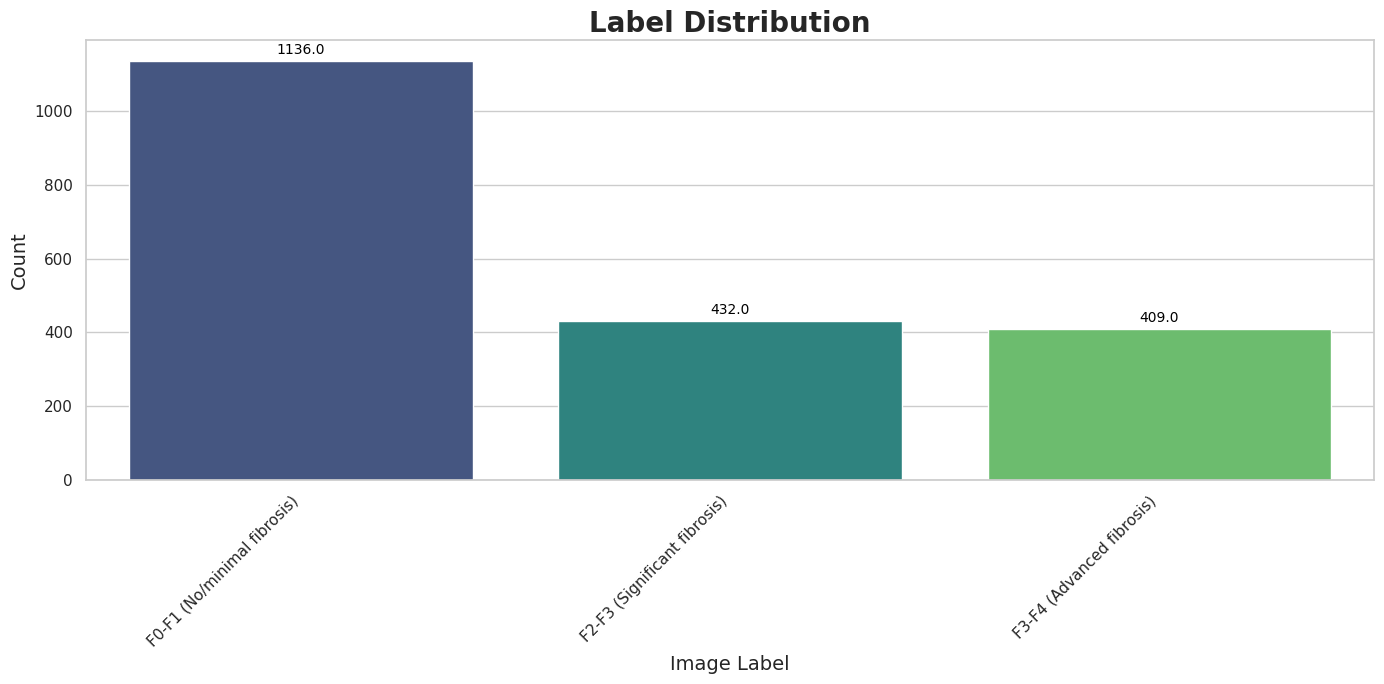

In [10]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, x='stage_fibrosis', palette='viridis', order=df['stage_fibrosis'].value_counts().index)

plt.title("Label Distribution", fontsize=20, fontweight='bold')
plt.xlabel("Image Label", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                textcoords='offset points')
plt.tight_layout()
plt.show()

In [11]:
df['stage_fibrosis'].unique()

array(['F0-F1 (No/minimal fibrosis)', 'F2-F3 (Significant fibrosis)',
       'F3-F4 (Advanced fibrosis)'], dtype=object)

> # ***Show Sample of Data*** 

In [12]:
df_F0 = df[df['stage_fibrosis']=='F0-F1 (No/minimal fibrosis)'].head(1)
df_F2 = df[df['stage_fibrosis']=='F2-F3 (Significant fibrosis)'].head(1)
df_F3 = df[df['stage_fibrosis']=='F3-F4 (Advanced fibrosis)'].head(1)

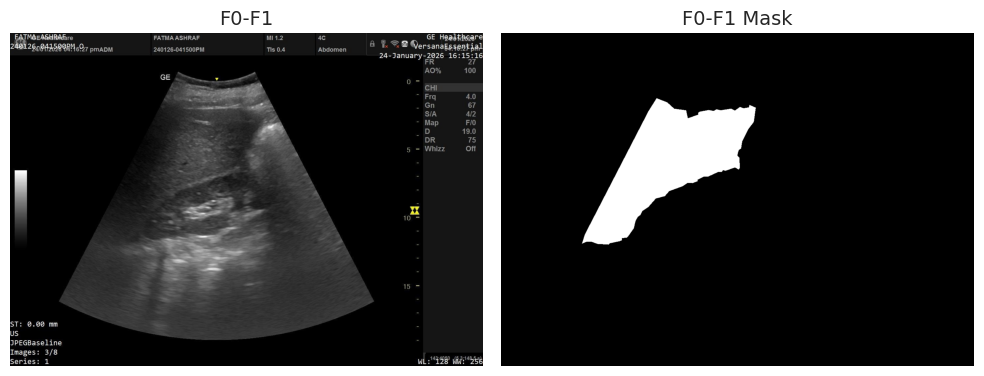

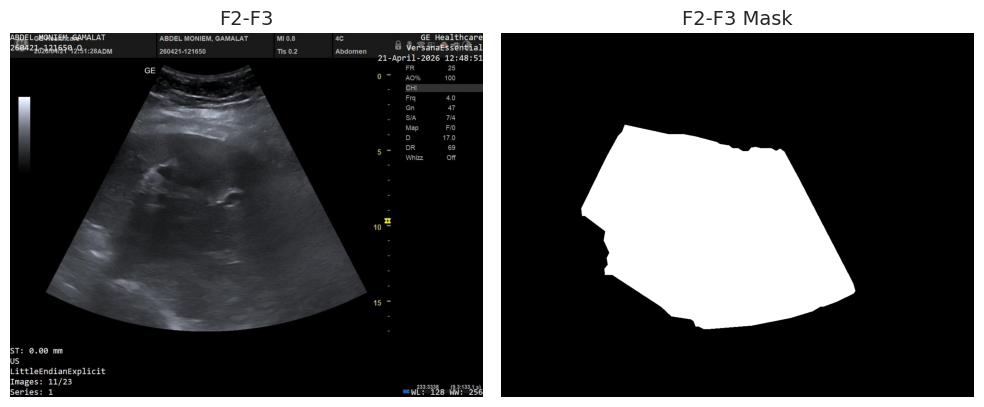

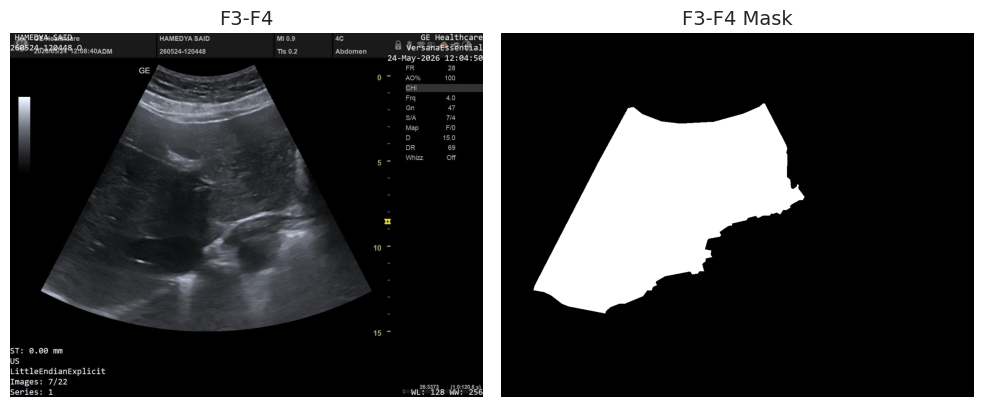

In [13]:
stage_fibrosis = {
    "F0-F1": df_F0,
    "F2-F3": df_F2,
    "F3-F4": df_F3
}

for fibrosis_name, df_fibrosis in stage_fibrosis.items():

    plt.figure(figsize=(10, 5))
    row = df_fibrosis.iloc[0]
    img = Image.open(row["image_path"])
    mask_path = row["mask_path"]

    if isinstance(mask_path, str):
        mask = Image.open(mask_path)
    else:
        mask = None
        
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(fibrosis_name, fontsize=14)
    plt.subplot(1, 2, 2)

    if mask is not None:
        plt.imshow(mask, cmap="gray")
        plt.title(f"{fibrosis_name} Mask", fontsize=14)
    else:
        plt.title("No Mask")

    plt.axis("off")

    plt.tight_layout()
    plt.show()

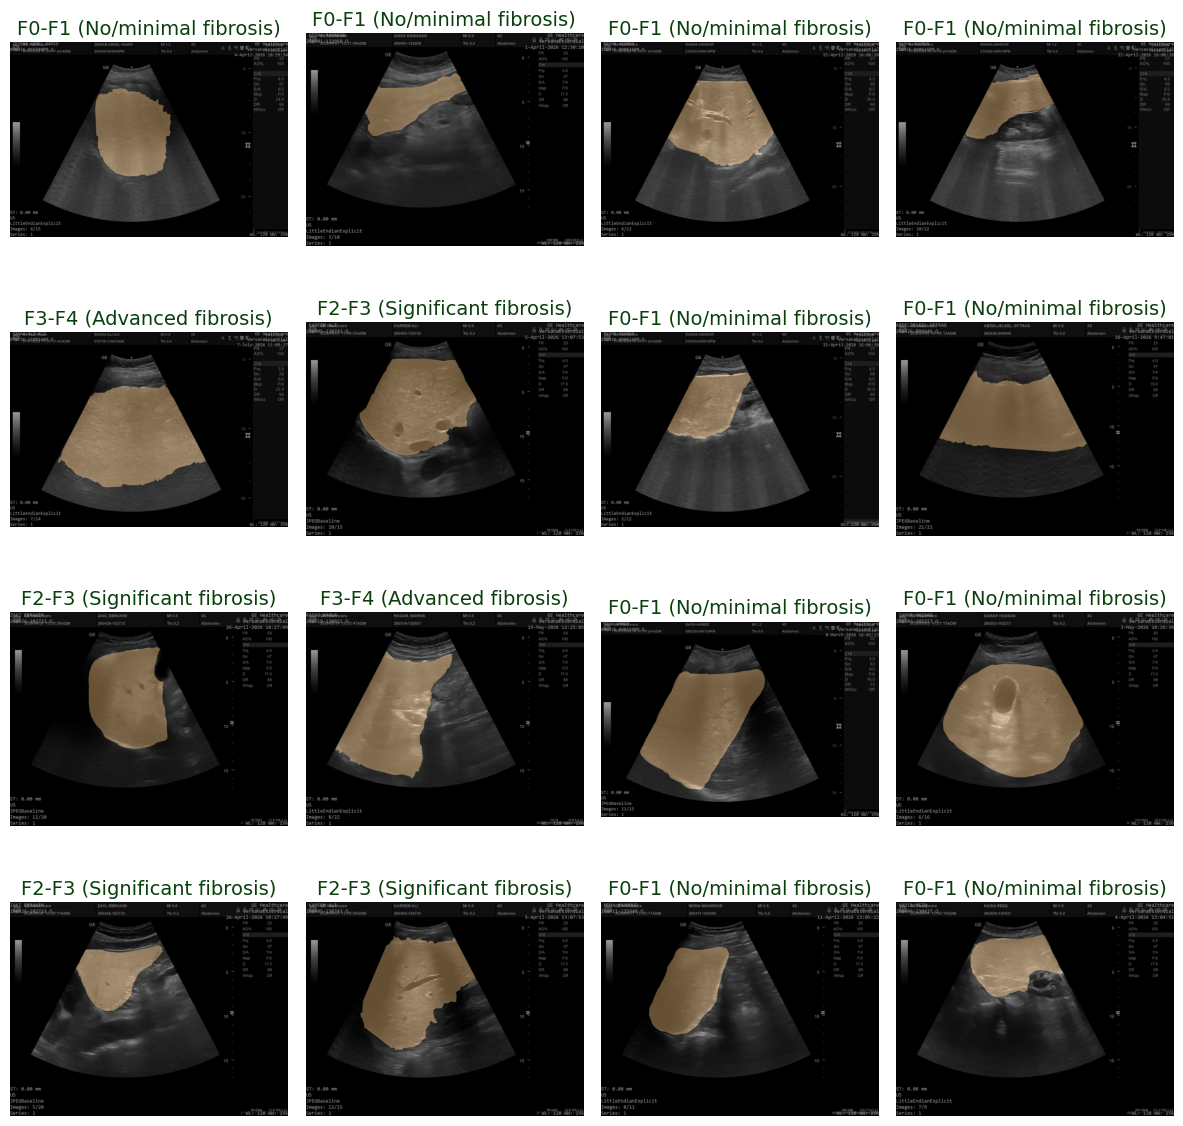

In [14]:
df = df.sample(frac=1).reset_index(drop=True)
plt.figure(figsize=(12, 12))

for i in range(16):
    img_path = df.iloc[i]['image_path']
    img = np.array(Image.open(img_path).convert("L"))
    mask_path = df.iloc[i]['mask_path']

    if isinstance(mask_path, list) and len(mask_path) > 0:
        mask_path = mask_path[0]

    if mask_path is not None:
        mask = np.array(Image.open(mask_path).convert("L"))
    else:
        mask = None
        
    plt.subplot(4, 4, i + 1)

    plt.imshow(img, cmap="gray")
    if mask is not None:
        plt.imshow(mask, cmap="copper", alpha=0.4)
    label_name = df.iloc[i]['stage_fibrosis']
    plt.title(label_name, color='#0A400C', fontsize=14)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
batchsize    = 32
image_height = 224
image_width  = 224
num_classes  = 3
epochs       = 200

In [16]:
tabular_df = df.drop([
    'image_path', 
    'mask_path',
    'name_only',
    'stage_fibrosis'
],axis=1)
image_df = df.drop([
       'name_only',
       'Age', 'DM', 'HTN', 'BMI', 'waist circumference (cm)', 'triglceride',
       'HDL', 'cholesterol', 'INR', 'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin',
       'Bilubin', 'weight in KG', 'height in cm ', 'Height *2',
       'Height in meter ', 'virology', 'MASLD'
],axis=1)

In [17]:
image_df.columns

Index(['image_path', 'mask_path', 'stage_fibrosis'], dtype='object')

In [18]:
tabular_df.columns

Index(['Age', 'DM', 'HTN', 'BMI', 'waist circumference (cm)', 'triglceride',
       'HDL', 'cholesterol', 'INR', 'FBG', 'HBAIC', 'ALT', 'AST', 'Albumin',
       'Bilubin', 'weight in KG', 'height in cm ', 'Height *2',
       'Height in meter ', 'virology', 'MASLD'],
      dtype='object')

> # ***Image DataFrame*** 

> # ***Split Data*** 

In [19]:
train_df, validation_df = train_test_split(
    df,
    test_size=0.1,
    shuffle=True,
    random_state=42,
    stratify=df['stage_fibrosis']
)

In [20]:
print("Train:", len(train_df))
print("Validation:", len(validation_df))

print("\nTrain distribution:")
print(train_df['stage_fibrosis'].value_counts(normalize=True))

print("\nValidation distribution:")
print(validation_df['stage_fibrosis'].value_counts(normalize=True))

Train: 1779
Validation: 198

Train distribution:
stage_fibrosis
F0-F1 (No/minimal fibrosis)     0.574480
F2-F3 (Significant fibrosis)    0.218662
F3-F4 (Advanced fibrosis)       0.206858
Name: proportion, dtype: float64

Validation distribution:
stage_fibrosis
F0-F1 (No/minimal fibrosis)     0.575758
F2-F3 (Significant fibrosis)    0.217172
F3-F4 (Advanced fibrosis)       0.207071
Name: proportion, dtype: float64


> # ***Label Encoder***

In [21]:
class_names = sorted(df['stage_fibrosis'].unique())
class_to_idx = {
    name: idx for idx, name in enumerate(class_names)
}
train_df['label_id'] = train_df['stage_fibrosis'].map(class_to_idx)
validation_df['label_id'] = validation_df['stage_fibrosis'].map(class_to_idx)

> # ***Tabular Dataset*** 

In [22]:
train_tabular = train_df[tabular_df.columns].copy()
validation_tabular = validation_df[tabular_df.columns].copy()

In [23]:
label_encoders = {}
categorical_cols= tabular_df.select_dtypes(include="object")
for col in categorical_cols:

    le = LabelEncoder()

    train_tabular[col] = le.fit_transform(
        train_tabular[col].astype(str)
    )

    validation_tabular[col] = le.transform(
        validation_tabular[col].astype(str)
    )

    label_encoders[col] = le

> # ***Scaler*** 

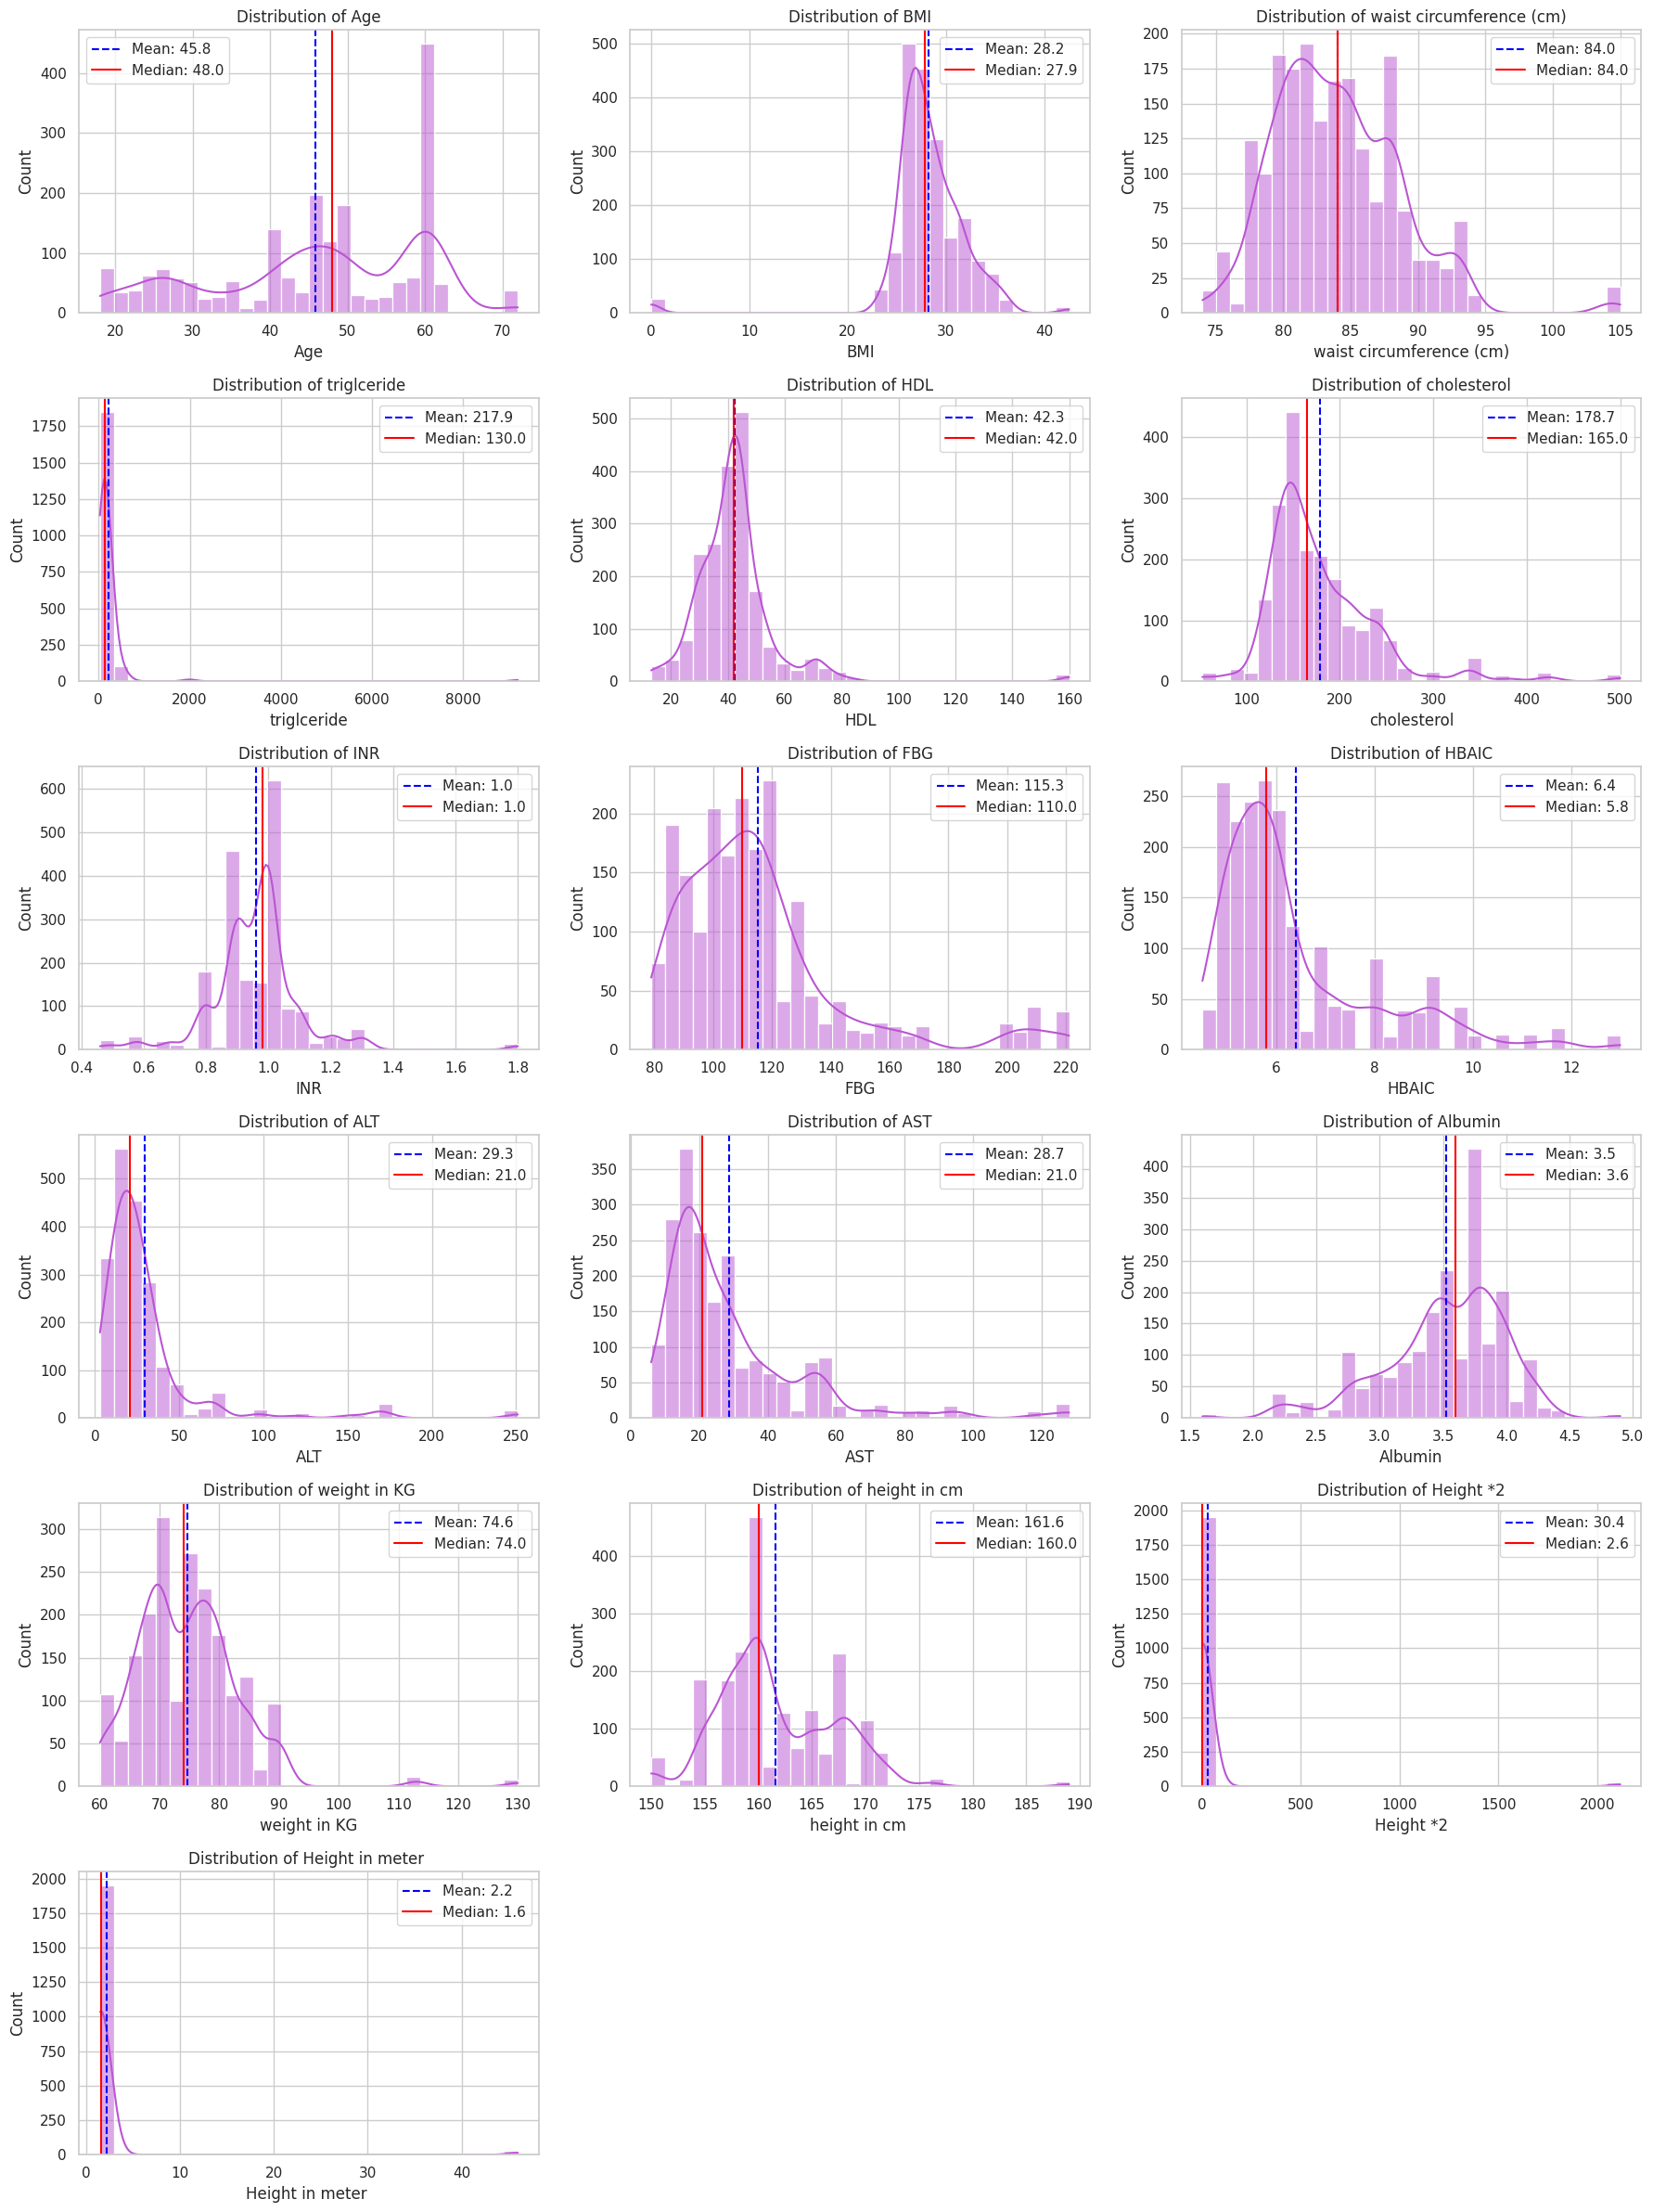

In [24]:
data = tabular_df.select_dtypes('number')
n_cols = 3
n_rows = (len(data.columns[:22]) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()


for i, col in enumerate(data.columns[:22]):
    sns.histplot(x=data[col], ax=axes[i], kde=True, bins=30,color='mediumorchid')


    mean_val = data[col].mean()
    median_val = data[col].median()


    axes[i].axvline(mean_val, color='blue', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='red', linestyle='-', label=f'Median: {median_val:.1f}')


    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend()


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [25]:
standard_cols = [
    'Age',
    'BMI',
    'waist circumference (cm)',
    'HDL',
    'cholesterol',
    'INR',
    'weight in KG'
]

robust_cols = [
    'FBG',
    'HBAIC',
    'ALT',
    'AST',
    'Albumin',
    'height in cm '
]

In [26]:
standard_scaler = StandardScaler()

train_tabular[standard_cols] = standard_scaler.fit_transform(
    train_tabular[standard_cols]
)

validation_tabular[standard_cols] = standard_scaler.transform(
    validation_tabular[standard_cols]
)

In [27]:
robust_scaler = RobustScaler()

train_tabular[robust_cols] = robust_scaler.fit_transform(
    train_tabular[robust_cols]
)

validation_tabular[robust_cols] = robust_scaler.transform(
    validation_tabular[robust_cols]
)

In [28]:
tabular_cols = tabular_df.columns

> # ***Load Image Mask*** 

In [29]:
def load_image_mask_tabular(
    image_path,
    mask_path,
    tabular,
    label
):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        (224, 224)
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0


    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(
        mask,
        channels=1
    )

    mask = tf.image.resize(
        mask,
        (224, 224)
    )

    mask = tf.cast(
        mask,
        tf.float32
    ) / 255.0


    return image, mask, tabular, label

In [30]:
def augment(
    image,
    mask,
    tabular,
    label
):

    seed = tf.random.uniform(
        [2],
        maxval=100000,
        dtype=tf.int32
    )

    image = tf.image.stateless_random_flip_left_right(
        image,
        seed=seed
    )

    mask = tf.image.stateless_random_flip_left_right(
        mask,
        seed=seed
    )

    return image, mask, tabular, label

> # Data Augmentation

On-the-fly augmentation was applied using a random horizontal flip to both the image and its corresponding mask with the same seed, ensuring proper alignment.

This approach does not create or store additional images, so it **saves storage space** while providing different image variations across training epochs. It is a **simple, lightweight, and storage-efficient** augmentation technique that helps reduce overfitting.


> # ***Combain Image & Mask***

In [31]:
def combine_image_mask(
    image,
    mask,
    tabular,
    label
):

    combined = tf.concat(
        [image, mask],
        axis=-1
    )

    return {
        "image_mask_input": combined,
        "tabular_input": tabular
    }, label

In [32]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df['image_path'].values,
        train_df['mask_path'].values,
        train_tabular.values.astype('float32'),
        train_df['label_id'].values
    )
)
train_ds = train_ds.map(
    load_image_mask_tabular,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.map(
    combine_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(batchsize)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

I0000 00:00:1790520400.863142      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790520400.866024      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [33]:
validation_ds = tf.data.Dataset.from_tensor_slices(
    (
        validation_df['image_path'].values,
        validation_df['mask_path'].values,
        validation_tabular.values.astype('float32'),
        validation_df['label_id'].values
    )
)

validation_ds = validation_ds.map(
    load_image_mask_tabular,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.map(
    combine_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.batch(batchsize)

validation_ds = validation_ds.prefetch(
    tf.data.AUTOTUNE
)

In [34]:
print("Train samples:", len(train_df))
print("Validation samples:", len(validation_df))

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_ds).numpy())

print("Batch size:", batchsize)

Train samples: 1779
Validation samples: 198
Train batches: 56
Validation batches: 7
Batch size: 32


> # ***Callback*** 

In [35]:
lr_callback   = callbacks.ReduceLROnPlateau(monitor= 'val_accuracy',factor = 0.1,patience=5)
stop_callback = callbacks.EarlyStopping(monitor= 'val_accuracy',patience=8)
model_ckpt = callbacks.ModelCheckpoint("densenet121_model.h5",save_best_only=True,monitor="val_accuracy",mode="max")

> # ***DenseNet121***

In [36]:
def build_model():

    # ==========================================
    # IMAGE + MASK INPUT
    # ==========================================

    image_input = layers.Input(
        shape=(224, 224, 4),
        name="image_mask_input"
    )

    x_img = layers.Conv2D(
        filters=3,
        kernel_size=1,
        padding='same',
        name='convert_4_to_3'
    )(image_input)


    # ==========================================
    # DENSENET121
    # ==========================================

    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )

    # Initially freeze DenseNet
    base_model.trainable = False

    x_img = base_model(
        x_img,
        training=False
    )

    x_img = layers.GlobalAveragePooling2D(
        name='image_gap'
    )(x_img)

    x_img = layers.BatchNormalization(
        name='image_bn'
    )(x_img)

    x_img = layers.Dropout(
        0.4,
        name='image_dropout'
    )(x_img)


    # ==========================================
    # TABULAR INPUT
    # ==========================================

    num_tabular_features = len(tabular_cols)

    tabular_input = layers.Input(
        shape=(num_tabular_features,),
        name="tabular_input"
    )

    x_tab = layers.Dense(
        128,
        activation='relu',
        name='tabular_dense_1'
    )(tabular_input)

    x_tab = layers.BatchNormalization(
        name='tabular_bn_1'
    )(x_tab)

    x_tab = layers.Dropout(
        0.3,
        name='tabular_dropout_1'
    )(x_tab)

    x_tab = layers.Dense(
        64,
        activation='relu',
        name='tabular_dense_2'
    )(x_tab)

    x_tab = layers.BatchNormalization(
        name='tabular_bn_2'
    )(x_tab)

    x_tab = layers.Dropout(
        0.3,
        name='tabular_dropout_2'
    )(x_tab)


    # ==========================================
    # FUSION
    # ==========================================

    combined = layers.Concatenate(
        name='feature_fusion'
    )([
        x_img,
        x_tab
    ])


    # ==========================================
    # CLASSIFICATION HEAD
    # ==========================================

    x = layers.Dense(
        128,
        activation='relu',
        name='fusion_dense'
    )(combined)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(
        0.4,
        name='fusion_dropout'
    )(x)

    output = layers.Dense(
        num_classes,
        activation='softmax',
        name='pred'
    )(x)


    # ==========================================
    # MODEL
    # ==========================================

    model = tf.keras.Model(
        inputs=[
            image_input,
            tabular_input
        ],
        outputs=output,
        name='DenseNet121_Image_Mask_Tabular'
    )


    # ==========================================
    # COMPILE
    # ==========================================

    optimizer = optimizers.Adam(
        learning_rate=1e-3
    )

    loss = losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    model.summary()

    return model

In [37]:
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    name='densenet121'
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [38]:
Dmodel = build_model()

Model: "DenseNet121_Image_Mask_Tabular"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_mask_input    │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dense_1     │ (None, 128)       │      2,816 │ tabular_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convert_4_to_3      │ (None, 224, 224,  │         15 │ image_mask_input… │
│ (Conv2D)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_bn_1        │ (None, 128)       │        512 │ tabular_dense_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ convert_4_to_3[0… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dropout_1   │ (None, 128)       │          0 │ tabular_bn_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_gap           │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dense_2     │ (None, 64)        │      8,256 │ tabular_dropout_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_bn            │ (None, 1024)      │      4,096 │ image_gap[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_bn_2        │ (None, 64)        │        256 │ tabular_dense_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dropout       │ (None, 1024)      │          0 │ image_bn[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_dropout_2   │ (None, 64)        │          0 │ tabular_bn_2[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 1088)      │          0 │ image_dropout[0]… │
│ (Concatenate)       │                   │            │ tabular_dropout_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 128)       │    139,392 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ fusion_dense[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 128)       │          0 │ batch_normalizat

 Total params: 7,193,746 (27.44 MB)

 Trainable params: 153,554 (599.82 KB)

 Non-trainable params: 7,040,192 (26.86 MB)

In [39]:
history = Dmodel.fit(
    train_ds,
    validation_data = validation_ds,
    callbacks = [lr_callback,model_ckpt],
    epochs = epochs,
    verbose =1
)

Epoch 1/200


2026-09-27 14:47:16.025531: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-27 14:47:16.173123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1790520451.951641     157 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.4171 - loss: 1.5795

2026-09-27 14:47:53.215047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-27 14:47:53.359762: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.4176 - loss: 1.5772

...

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.7083 - loss: 0.6947 - val_accuracy: 0.7121 - val_loss: 0.6847 - learning_rate: 0.0010
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 0.7088 - loss: 0.6625 - val_accuracy: 0.6869 - val_loss: 0.6717 - learning_rate: 0.0010
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.7431 - loss: 0.6179 - val_accuracy: 0.7121 - val_loss: 0.6445 - learning_rate: 0.0010
Epoch 8/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7524 - loss: 0.5636

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.7538 - loss: 0.5726 - val_accuracy: 0.7374 - val_loss: 0.5900 - learning_rate: 0.0010
Epoch 9/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 166ms/step - accuracy: 0.7813 - loss: 0.5383 - val_accuracy: 0.7222 - val_loss: 0.5965 - learning_rate: 0.0010
Epoch 10/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7840 - loss: 0.5227

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.7847 - loss: 0.5194 - val_accuracy: 0.7677 - val_loss: 0.5513 - learning_rate: 0.0010
Epoch 11/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.7960 - loss: 0.5002 - val_accuracy: 0.7525 - val_loss: 0.5596 - learning_rate: 0.0010
Epoch 12/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8145 - loss: 0.4609

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.8027 - loss: 0.4798 - val_accuracy: 0.7879 - val_loss: 0.5262 - learning_rate: 0.0010
Epoch 13/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.8094 - loss: 0.4653 - val_accuracy: 0.7525 - val_loss: 0.5341 - learning_rate: 0.0010
Epoch 14/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.8437 - loss: 0.4007 - val_accuracy: 0.7576 - val_loss: 0.5245 - learning_rate: 0.0010
Epoch 15/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.8347 - loss: 0.4225 - val_accuracy: 0.7475 - val_loss: 0.5419 - learning_rate: 0.0010
Epoch 16/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.8359 - loss: 0.4045 - val_accuracy: 0.7727 - val_loss: 0.5215 - learning_rate: 0.0010
Epoch 17/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.8387 - loss: 0.3939 - val_accuracy: 0.7828 - val_loss: 0.5093 - learning_rate: 0.0010
Epoch 18/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.8561 - loss: 0

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - accuracy: 0.8623 - loss: 0.3451 - val_accuracy: 0.7929 - val_loss: 0.4534 - learning_rate: 1.0000e-04
Epoch 21/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.8730 - loss: 0.3347 - val_accuracy: 0.7929 - val_loss: 0.4512 - learning_rate: 1.0000e-04
Epoch 22/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.8814 - loss: 0.3218 - val_accuracy: 0.7929 - val_loss: 0.4473 - learning_rate: 1.0000e-04
Epoch 23/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.8797 - loss: 0.3295 - val_accuracy: 0.7929 - val_loss: 0.4379 - learning_rate: 1.0000e-04
Epoch 24/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.8814 - loss: 0.3331 - val_accuracy: 0.7929 - val_loss: 0.4319 - learning_rate: 1.0000e-04
Epoch 25/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.8797 - loss: 0.3196 - val_accuracy: 0.7929 - val_loss: 0.4273 - learning_rate: 1.0000e-04
Epoch 26/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - ac

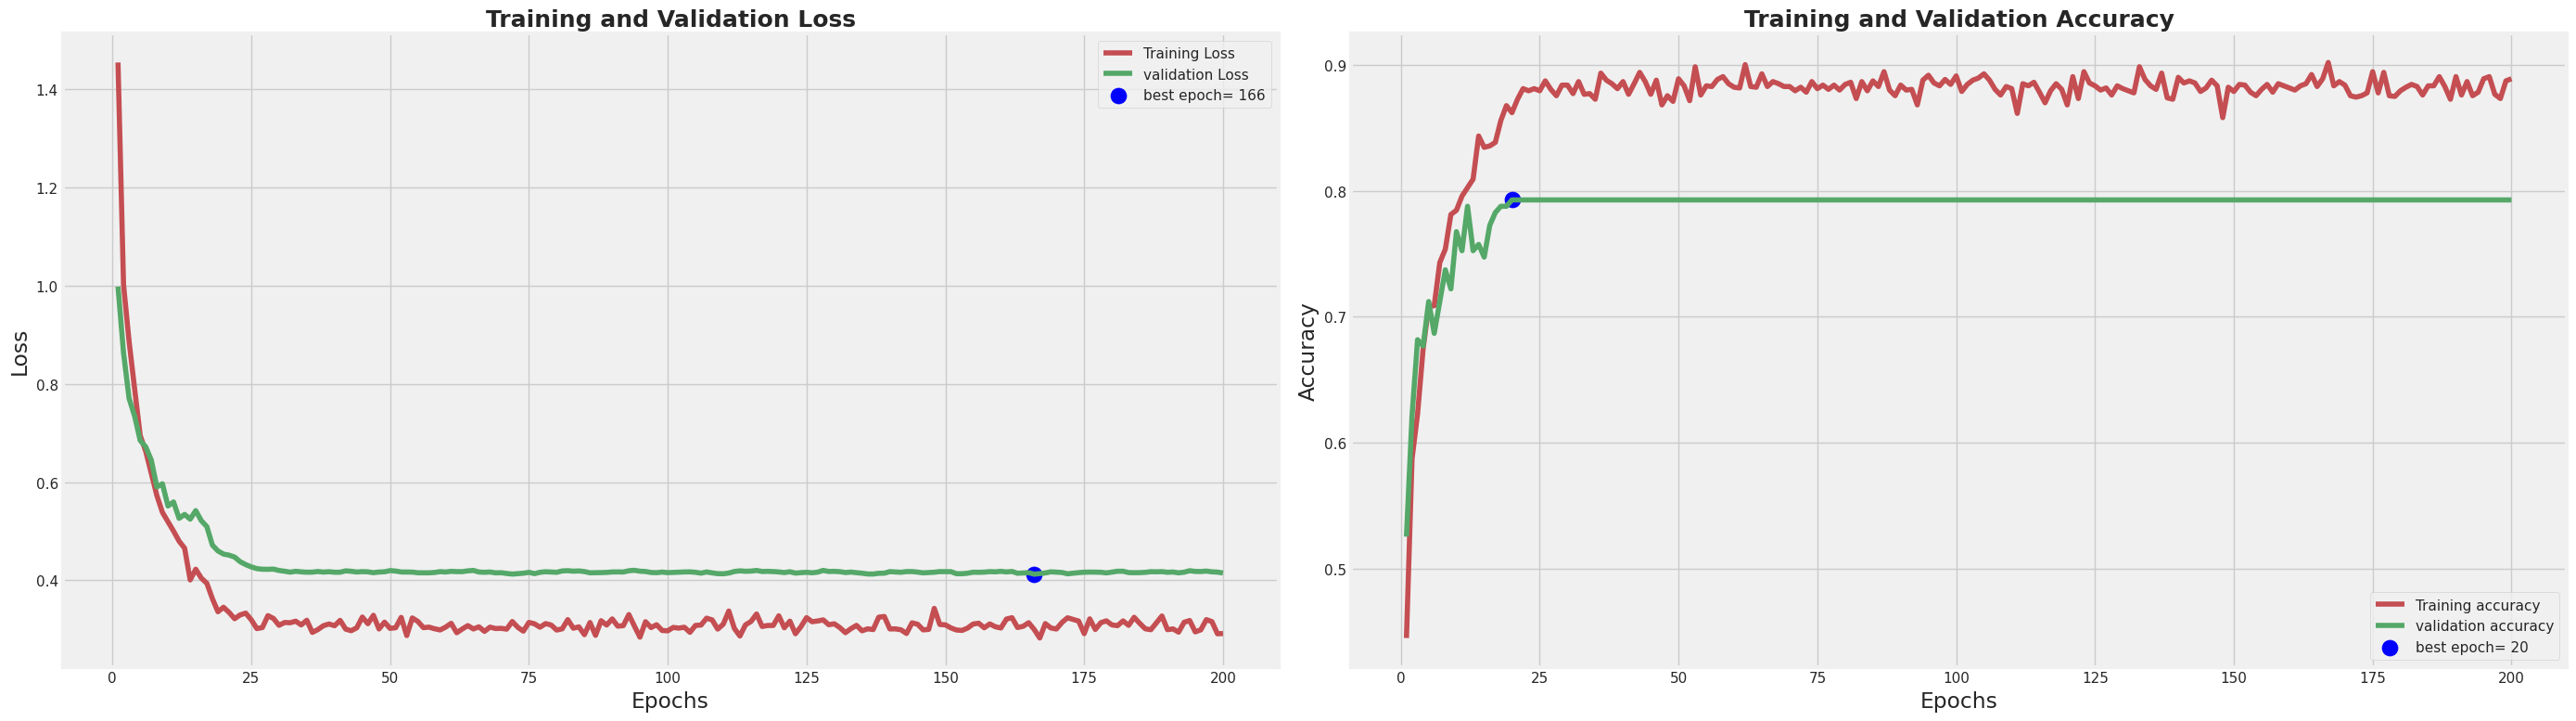

In [40]:
tr_acc   = history.history['accuracy']
tr_loss  = history.history['loss']
val_acc  = history.history['val_accuracy']
val_loss = history.history['val_loss']

idx_loss   = np.argmin(val_loss)
val_lowest = val_loss[idx_loss]
idx_acc    = np.argmax(val_acc)
val_highest= val_acc[idx_acc]

Epochs =[i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(idx_loss + 1)}'
acc_label = f'best epoch= {str(idx_acc + 1)}'

plt.figure(figsize=(28,8))
plt.style.use("fivethirtyeight")

plt.subplot(1,2,1)
plt.plot(Epochs,tr_loss,'r',label='Training Loss')
plt.plot(Epochs,val_loss,'g',label='validation Loss')
plt.scatter(idx_loss+1,val_lowest,s=150,c='blue',label= loss_label)
plt.title('Training and Validation Loss',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs,tr_acc,'r',label='Training accuracy')
plt.plot(Epochs,val_acc,'g',label='validation accuracy')
plt.scatter(idx_acc+1,val_highest,s=150,c='blue',label= acc_label)
plt.title('Training and Validation Accuracy',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(
    "training_curves_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [41]:
y_test = []
y_pred = []

for inputs, labels in validation_ds:

    preds = Dmodel.predict(
        inputs,
        verbose=0
    )

    preds = np.argmax(
        preds,
        axis=1
    )

    y_pred.extend(preds)
    y_test.extend(labels.numpy())

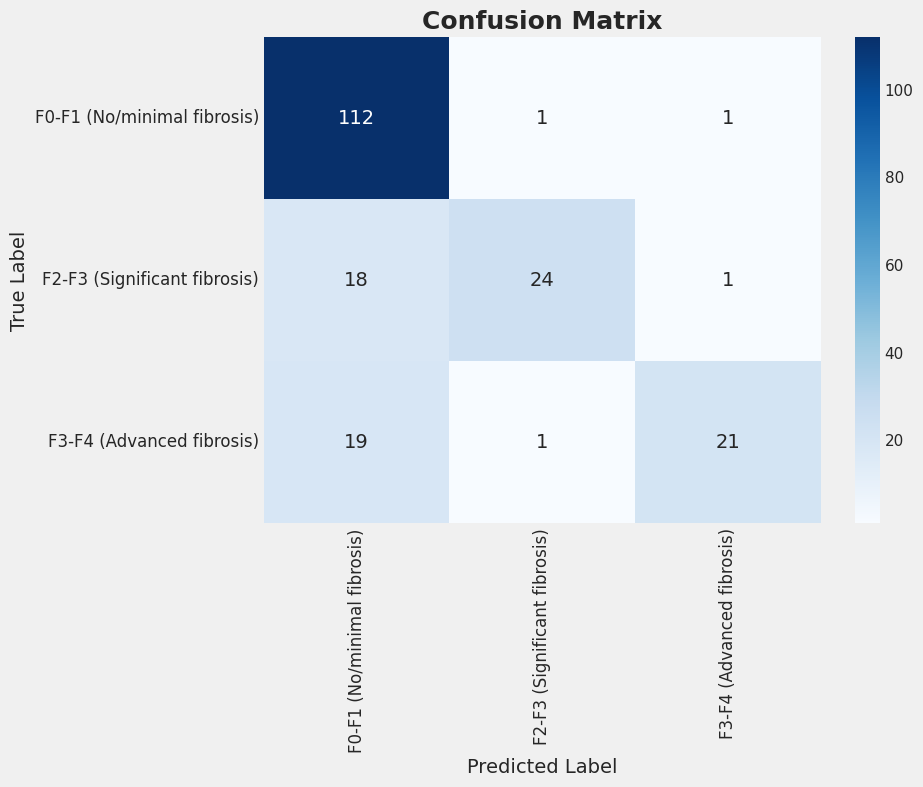

 Classification Report:

                              precision    recall  f1-score   support

 F0-F1 (No/minimal fibrosis)       0.75      0.98      0.85       114
F2-F3 (Significant fibrosis)       0.92      0.56      0.70        43
   F3-F4 (Advanced fibrosis)       0.91      0.51      0.66        41

                    accuracy                           0.79       198
                   macro avg       0.86      0.68      0.73       198
                weighted avg       0.82      0.79      0.78       198

 Accuracy Score: 0.7929


In [42]:
con = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(con, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(
    "Confusion_matrix_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(" Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))
print(f" Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

In [43]:
Dmodel.save("Transfer_DenseNet121.h5")

> # ***Partial Fine Tuning*** 

In [44]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

In [45]:
Dmodel.compile(
    optimizer=optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [46]:
history_ft = Dmodel.fit(
    train_ds,
    validation_data=validation_ds,
    callbacks=[lr_callback, model_ckpt],
    epochs=100,
    verbose=1
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 81s 864ms/step - accuracy: 0.8606 - loss: 0.3300 - val_accuracy: 0.7929 - val_loss: 0.4139 - learning_rate: 1.0000e-05
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8907 - loss: 0.2886

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.8859 - loss: 0.3020 - val_accuracy: 0.7980 - val_loss: 0.4152 - learning_rate: 1.0000e-05
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.8825 - loss: 0.3198 - val_accuracy: 0.7929 - val_loss: 0.4150 - learning_rate: 1.0000e-05
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.8926 - loss: 0.2951 - val_accuracy: 0.7929 - val_loss: 0.4148 - learning_rate: 1.0000e-05
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step - accuracy: 0.8831 - loss: 0.3018 - val_accuracy: 0.7929 - val_loss: 0.4160 - learning_rate: 1.0000e-05
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - accuracy: 0.8848 - loss: 0.3036 - val_accuracy: 0.7929 - val_loss: 0.4164 - learning_rate: 1.0000e-05
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.8758 - loss: 0.3181 - val_accuracy: 0.7929 - val_loss: 0.4137 - learning_rate: 1.0000e-05
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy

56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.8971 - loss: 0.2780 - val_accuracy: 0.8030 - val_loss: 0.4118 - learning_rate: 1.0000e-18
Epoch 73/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.8758 - loss: 0.3261 - val_accuracy: 0.7929 - val_loss: 0.4141 - learning_rate: 1.0000e-18
Epoch 74/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.8842 - loss: 0.3123 - val_accuracy: 0.7929 - val_loss: 0.4142 - learning_rate: 1.0000e-18
Epoch 75/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.8780 - loss: 0.3031 - val_accuracy: 0.7929 - val_loss: 0.4132 - learning_rate: 1.0000e-18
Epoch 76/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.8960 - loss: 0.3012 - val_accuracy: 0.7929 - val_loss: 0.4164 - learning_rate: 1.0000e-18
Epoch 77/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.8881 - loss: 0.2921 - val_accuracy: 0.7929 - val_loss: 0.4168 - learning_rate: 1.0000e-18
Epoch 78/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - ac

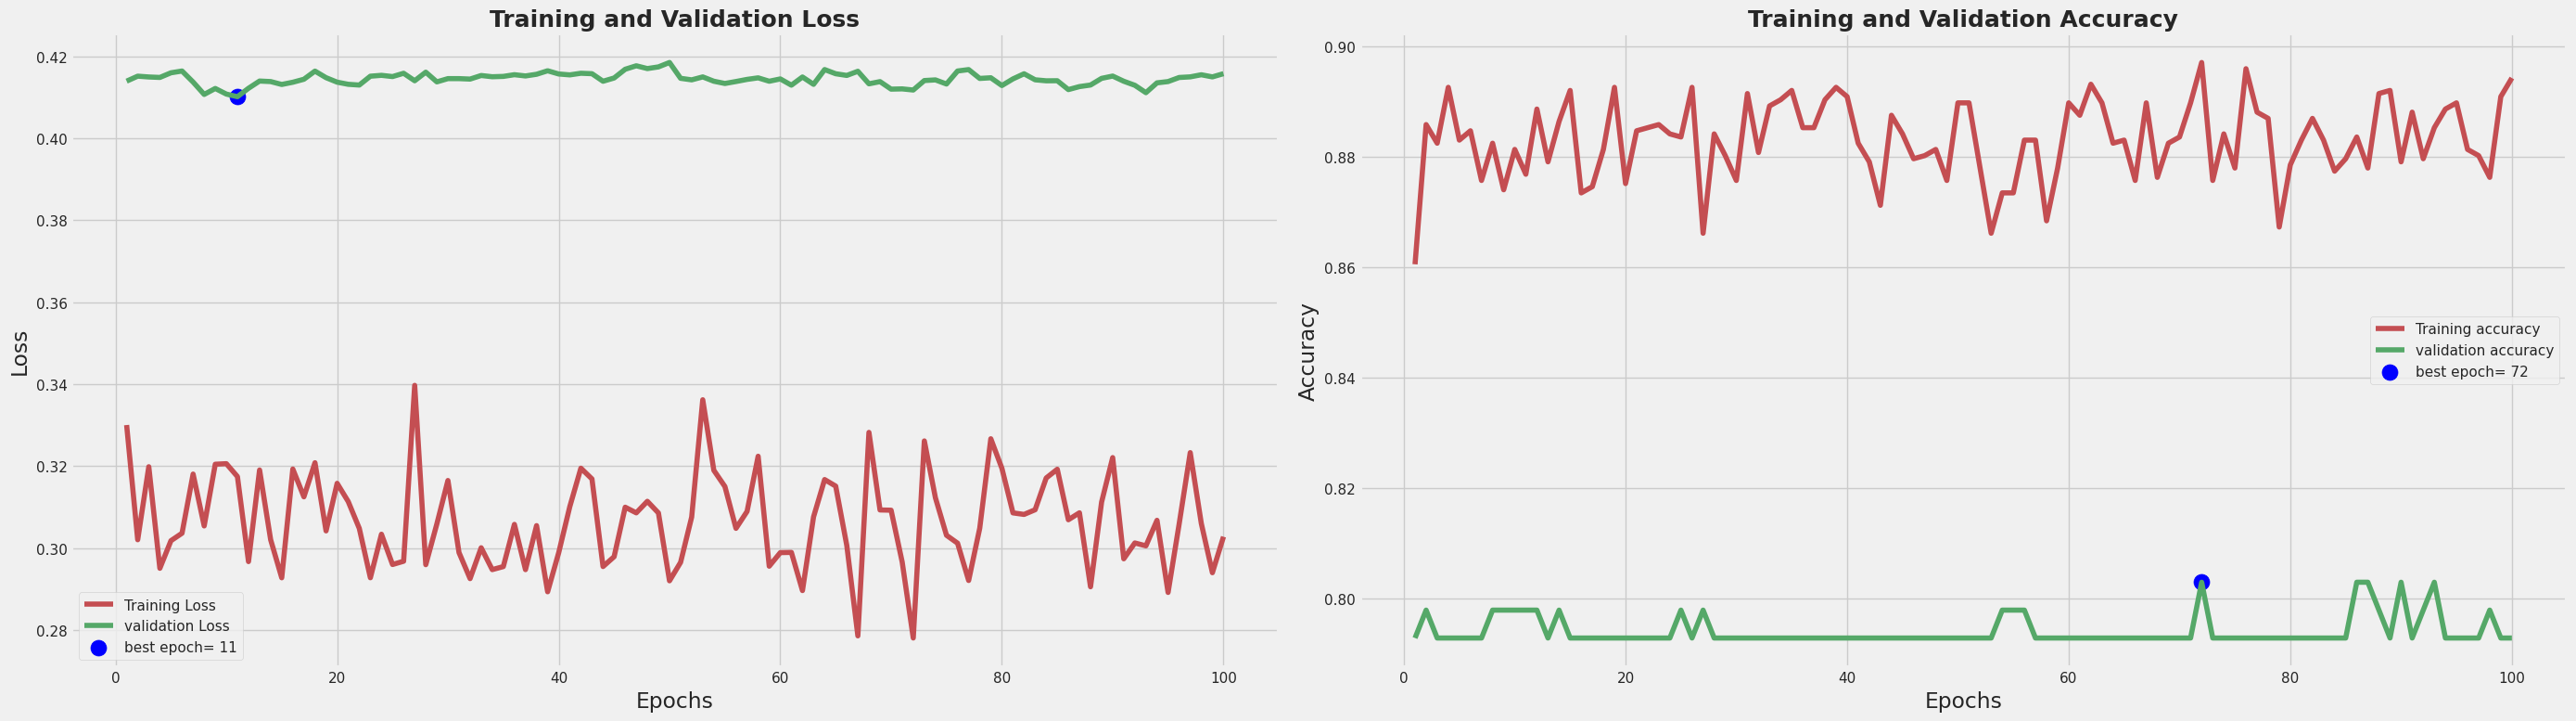

In [47]:
tr_acc   = history_ft.history['accuracy']
tr_loss  = history_ft.history['loss']
val_acc  = history_ft.history['val_accuracy']
val_loss = history_ft.history['val_loss']

idx_loss   = np.argmin(val_loss)
val_lowest = val_loss[idx_loss]
idx_acc    = np.argmax(val_acc)
val_highest= val_acc[idx_acc]

Epochs =[i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(idx_loss + 1)}'
acc_label = f'best epoch= {str(idx_acc + 1)}'

plt.figure(figsize=(28,8))
plt.style.use("fivethirtyeight")

plt.subplot(1,2,1)
plt.plot(Epochs,tr_loss,'r',label='Training Loss')
plt.plot(Epochs,val_loss,'g',label='validation Loss')
plt.scatter(idx_loss+1,val_lowest,s=150,c='blue',label= loss_label)
plt.title('Training and Validation Loss',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs,tr_acc,'r',label='Training accuracy')
plt.plot(Epochs,val_acc,'g',label='validation accuracy')
plt.scatter(idx_acc+1,val_highest,s=150,c='blue',label= acc_label)
plt.title('Training and Validation Accuracy',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(
    "training_curves_Partial_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [48]:
y_test = []
y_pred = []

for inputs, labels in validation_ds:

    preds = Dmodel.predict(
        inputs,
        verbose=0
    )

    preds = np.argmax(
        preds,
        axis=1
    )

    y_pred.extend(preds)
    y_test.extend(labels.numpy())

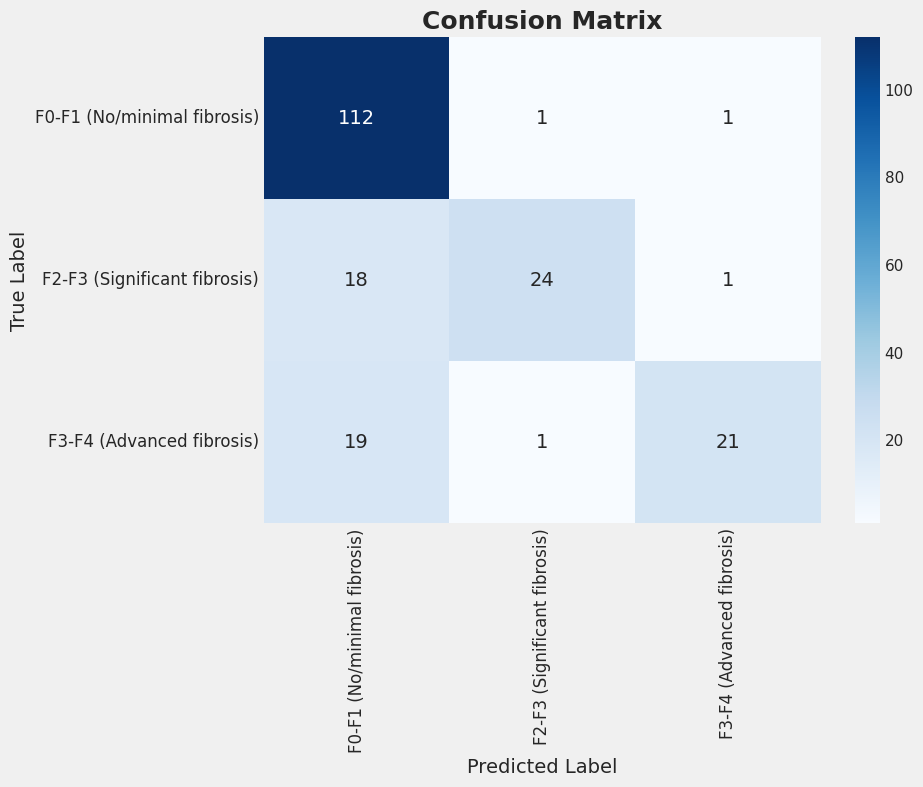

 Classification Report:

                              precision    recall  f1-score   support

 F0-F1 (No/minimal fibrosis)       0.75      0.98      0.85       114
F2-F3 (Significant fibrosis)       0.92      0.56      0.70        43
   F3-F4 (Advanced fibrosis)       0.91      0.51      0.66        41

                    accuracy                           0.79       198
                   macro avg       0.86      0.68      0.73       198
                weighted avg       0.82      0.79      0.78       198

 Accuracy Score: 0.7929


In [49]:
con = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(con, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(
    "Confusion_matrix_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(" Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))
print(f" Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

In [50]:
Dmodel.save("Partial_DenseNet121.h5")

> # ***Save PreProcessing*** 

In [55]:
import joblib


joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)
joblib.dump(
    standard_scaler,
    "standard_scaler.pkl"
)

joblib.dump(
    robust_scaler,
    "robust_scaler.pkl"
)

print("Preprocessing objects saved successfully!")

Preprocessing objects saved successfully!
